# EEG Mental Arithmetic (PhysioNet `eegmat`)

Источник данных: `https://physionet.org/files/eegmat/1.0.0/`.

Цель: выполнить обработку ЭЭГ и оценить функциональное состояние испытуемого в двух условиях:
- `*_1.edf`: фоновая ЭЭГ до задания.
- `*_2.edf`: ЭЭГ во время ментальной арифметики.


### План
1. Загрузка EDF и метаданных `subject-info.csv`.
2. Предобработка: выбор EEG-каналов, референс, полосовая фильтрация 1-40 Гц.
3. Эпохирование фиксированными окнами.
4. Расчет мощности ритмов (`Theta/Alpha/Beta/Gamma`) и индекса `Alpha/Beta`.
5. Сравнение состояний в фоне и при задаче для одного испытуемого.
6. Групповое сравнение (`Count quality`: 0 = группа B, 1 = группа G).


In [ ]:
%pip install -q mne pandas numpy matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import seaborn as sns

DATA_DIR = Path("eeg-during-mental-arithmetic-tasks-1.0.0")
INFO_CSV = DATA_DIR / "subject-info.csv"

# Для быстрой отладки можно ограничить число субъектов
MAX_SUBJECTS = None

BANDS = {
    "Theta": (4, 7),
    "Alpha": (8, 12),
    "Beta": (13, 25),
    "Gamma": (30, 40),
}

In [ ]:
subject_info = pd.read_csv(INFO_CSV)
subject_info["group"] = subject_info["Count quality"].map({0: "B", 1: "G"})
subject_info.head()

,Subject,Age,Gender,Recording year,Number of subtractions,Count quality,group
0,Subject00,21,F,2011,9.70,0,B
1,Subject01,18,F,2011,29.35,1,G
2,Subject02,19,F,2012,12.88,1,G
3,Subject03,17,F,2010,31.00,1,G
4,Subject04,17,F,2010,8.60,0,B


In [ ]:
edf_files = sorted(DATA_DIR.glob("Subject*_*.edf"))

rows = []
pattern = re.compile(r"(Subject\d+)_(\d)\.edf$")
for p in edf_files:
    m = pattern.search(p.name)
    if not m:
        continue
    subject, rec = m.group(1), m.group(2)
    condition = "background" if rec == "1" else "task"
    rows.append({"subject": subject, "record": rec, "condition": condition, "path": p})

edf_index = pd.DataFrame(rows).sort_values(["subject", "record"]).reset_index(drop=True)

if MAX_SUBJECTS is not None:
    keep_subjects = edf_index["subject"].drop_duplicates().head(MAX_SUBJECTS)
    edf_index = edf_index[edf_index["subject"].isin(keep_subjects)].reset_index(
        drop=True
    )

edf_index.head(10)

,subject,record,condition,path
0,Subject00,1,background,eeg-during-mental-arithmetic-tasks-1.0.0/Subje...
1,Subject00,2,task,eeg-during-mental-arithmetic-tasks-1.0.0/Subje...
2,Subject01,1,background,eeg-during-mental-arithmetic-tasks-1.0.0/Subje...
3,Subject01,2,task,eeg-during-mental-arithmetic-tasks-1.0.0/Subje...
4,Subject02,1,background,eeg-during-mental-arithmetic-tasks-1.0.0/Subje...
5,Subject02,2,task,eeg-during-mental-arithmetic-tasks-1.0.0/Subje...
6,Subject03,1,background,eeg-during-mental-arithmetic-tasks-1.0.0/Subje...
7,Subject03,2,task,eeg-during-mental-arithmetic-tasks-1.0.0/Subje...
8,Subject04,1,background,eeg-during-mental-arithmetic-tasks-1.0.0/Subje...
9,Subject04,2,task,eeg-during-mental-arithmetic-tasks-1.0.0/Subje...


In [ ]:
def preprocess_raw(path: Path) -> mne.io.Raw:
    raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
    raw.pick("eeg")
    raw.set_eeg_reference("average", verbose=False)
    raw.filter(l_freq=1.0, h_freq=40.0, fir_design="firwin", verbose=False)
    return raw


def epochs_from_raw(
    raw: mne.io.Raw, duration: float = 2.0, overlap: float = 1.0
) -> mne.Epochs:
    events = mne.make_fixed_length_events(raw, id=1, duration=duration, overlap=overlap)
    epochs = mne.Epochs(
        raw,
        events,
        event_id={"seg": 1},
        tmin=0,
        tmax=duration,
        baseline=None,
        preload=True,
        verbose=False,
    )
    return epochs


def band_powers(epochs: mne.Epochs, bands: dict) -> pd.DataFrame:
    sfreq = epochs.info["sfreq"]
    n_fft = int(max(256, sfreq * 2))
    psd = epochs.compute_psd(
        method="welch", fmin=1, fmax=40, n_fft=n_fft, verbose=False
    )
    psds = psd.get_data() # (n_epochs, n_channels, n_freqs)
    freqs = psd.freqs

    out = pd.DataFrame(index=np.arange(psds.shape[0]))
    for band_name, (fmin, fmax) in bands.items():
        idx = (freqs >= fmin) & (freqs <= fmax)
        out[band_name] = psds[:, :, idx].mean(axis=(1, 2))

    out["alpha_beta"] = out["Alpha"] / (out["Beta"] + 1e-12)
    out["theta_beta"] = out["Theta"] / (out["Beta"] + 1e-12)
    return out

In [ ]:
all_epoch_features = []

for row in edf_index.itertuples(index=False):
    raw = preprocess_raw(row.path)
    epochs = epochs_from_raw(raw, duration=2.0, overlap=1.0)
    feats = band_powers(epochs, BANDS)
    feats["subject"] = row.subject
    feats["condition"] = row.condition
    feats["epoch_idx"] = np.arange(len(feats))
    all_epoch_features.append(feats)

features_df = pd.concat(all_epoch_features, ignore_index=True)
features_df = features_df.merge(
    subject_info[["Subject", "Count quality", "group", "Number of subtractions"]],
    left_on="subject",
    right_on="Subject",
    how="left",
)
features_df.head()

,Theta,Alpha,Beta,Gamma,alpha_beta,theta_beta,subject,condition,epoch_idx,Subject,Count quality,group,Number of subtractions
0,5.862822e-11,4.823218e-11,8.098748e-12,2.753114e-13,5.300969,6.443548,Subject00,background,0,Subject00,0,B,9.7
1,5.282514e-11,4.090295e-11,9.116407e-12,2.656965e-13,4.043229,5.221730,Subject00,background,1,Subject00,0,B,9.7
2,4.706788e-11,3.636374e-11,8.417301e-12,2.694661e-13,3.861376,4.998022,Subject00,background,2,Subject00,0,B,9.7
3,5.120960e-11,3.715522e-11,8.807803e-12,2.622830e-13,3.788332,5.221312,Subject00,background,3,Subject00,0,B,9.7
4,5.705234e-11,4.248120e-11,9.936403e-12,2.651238e-13,3.884385,5.216737,Subject00,background,4,Subject00,0,B,9.7


In [ ]:
# Сводка по каждому субъекту и условию
subject_condition = features_df.groupby(
    ["subject", "condition", "group", "Count quality"], as_index=False
)[["Theta", "Alpha", "Beta", "Gamma", "alpha_beta", "theta_beta"]].mean()
subject_condition.head()

,subject,condition,group,Count quality,Theta,Alpha,Beta,Gamma,alpha_beta,theta_beta
0,Subject00,background,B,0,4.819884e-11,4.179168e-11,9.109676e-12,3.021666e-13,4.136817,4.793652
1,Subject00,task,B,0,3.593370e-11,4.657195e-11,1.044819e-11,3.739776e-13,4.063957,3.172665
2,Subject01,background,G,1,1.864109e-11,1.268041e-11,3.181411e-12,6.315627e-13,3.034548,4.365277
3,Subject01,task,G,1,1.671983e-11,9.140420e-12,2.883902e-12,9.292639e-13,2.327301,4.050453
4,Subject02,background,G,1,1.973994e-12,4.246655e-12,1.144898e-12,3.012381e-13,1.875355,0.919508


In [ ]:
# Переход от фона к задаче
pivot = subject_condition.pivot_table(
    index=["subject", "group", "Count quality"],
    columns="condition",
    values=["Theta", "Alpha", "Beta", "Gamma", "alpha_beta", "theta_beta"],
)

# Flatten multi-index columns
pivot.columns = [f"{metric}_{cond}" for metric, cond in pivot.columns]
pivot = pivot.reset_index()

pivot["delta_alpha_beta"] = pivot["alpha_beta_task"] - pivot["alpha_beta_background"]
pivot["delta_beta"] = pivot["Beta_task"] - pivot["Beta_background"]

pivot.head()

,subject,group,Count quality,Alpha_background,Alpha_task,Beta_background,Beta_task,Gamma_background,Gamma_task,Theta_background,Theta_task,alpha_beta_background,alpha_beta_task,theta_beta_background,theta_beta_task,delta_alpha_beta,delta_beta
0,Subject00,B,0,4.179168e-11,4.657195e-11,9.109676e-12,1.044819e-11,3.021666e-13,3.739776e-13,4.819884e-11,3.593370e-11,4.136817,4.063957,4.793652,3.172665,-0.072860,1.338513e-12
1,Subject01,G,1,1.268041e-11,9.140420e-12,3.181411e-12,2.883902e-12,6.315627e-13,9.292639e-13,1.864109e-11,1.671983e-11,3.034548,2.327301,4.365277,4.050453,-0.707248,-2.975093e-13
2,Subject02,G,1,4.246655e-12,1.163853e-11,1.144898e-12,8.739447e-12,3.012381e-13,1.641713e-12,1.973994e-12,1.504544e-11,1.875355,1.197188,0.919508,1.556834,-0.678167,7.594549e-12
3,Subject03,G,1,1.595608e-11,1.306102e-11,3.373100e-12,3.777510e-12,3.925096e-13,5.263203e-13,1.331323e-11,1.182925e-11,3.673486,2.739846,3.099604,2.501318,-0.933640,4.044101e-13
4,Subject04,B,0,1.412581e-11,1.314621e-11,5.282223e-12,5.546471e-12,5.808010e-13,3.273190e-13,1.410605e-11,1.103261e-11,2.270533,2.012142,2.315625,1.696933,-0.258391,2.642486e-13


In [ ]:
# Групповое сравнение (B vs G)
group_stats = pivot.groupby("group", as_index=False)[
    ["alpha_beta_background", "alpha_beta_task", "delta_alpha_beta", "delta_beta"]
].agg(["mean", "std"])
group_stats

group alpha_beta_background           alpha_beta_task            \
                         mean       std            mean       std   
0     B              2.104876  0.839421        1.868373  0.839393   
1     G              2.374052  0.754498        2.127695  0.697117   

  delta_alpha_beta              delta_beta                
              mean       std          mean           std  
0        -0.236503  0.318212  1.187080e-12  1.526121e-12  
1        -0.246357  0.477174  3.846773e-13  4.156561e-12

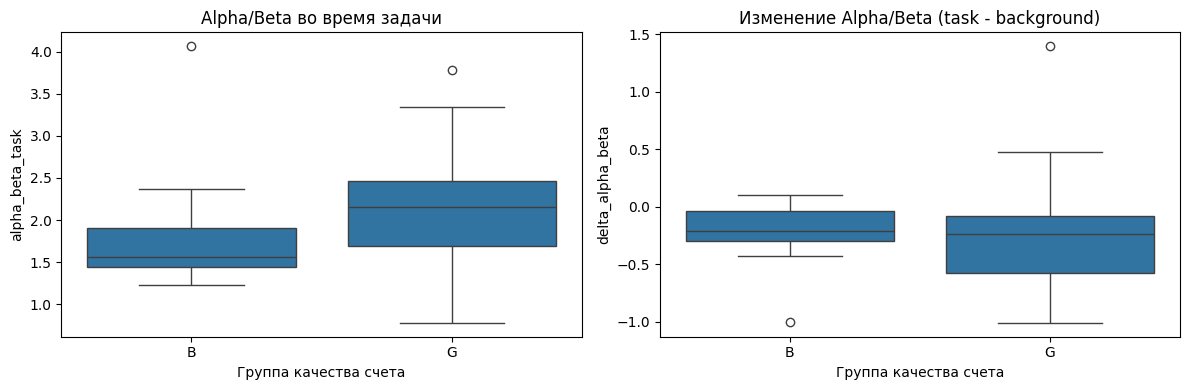

In [ ]:
# Графики распределения ключевых индексов по группам
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=pivot, x="group", y="alpha_beta_task", ax=axes[0])
axes[0].set_title("Alpha/Beta во время задачи")
axes[0].set_xlabel("Группа качества счета")

sns.boxplot(data=pivot, x="group", y="delta_alpha_beta", ax=axes[1])
axes[1].set_title("Изменение Alpha/Beta (task - background)")
axes[1].set_xlabel("Группа качества счета")

plt.tight_layout()

In [ ]:
pivot[
    ["subject", "alpha_beta_background", "alpha_beta_task", "delta_alpha_beta"]
].sort_values("alpha_beta_background", ascending=False).head(10)

,subject,alpha_beta_background,alpha_beta_task,delta_alpha_beta
0,Subject00,4.136817,4.063957,-0.072860
16,Subject16,3.761260,3.777459,0.016199
3,Subject03,3.673486,2.739846,-0.933640
18,Subject18,3.442286,3.080347,-0.361939
17,Subject17,3.439397,3.337174,-0.102223
1,Subject01,3.034548,2.327301,-0.707248
23,Subject23,2.862463,2.606923,-0.255540
27,Subject27,2.828901,2.856245,0.027344
33,Subject33,2.763841,1.752215,-1.011625
34,Subject34,2.716760,2.118581,-0.598179


condition   state                              
background  Умеренная активность                   54.4
            Напряженная умственная деятельность    22.8
            Расслабленное                          22.8
task        Умеренная активность                   63.3
            Напряженная умственная деятельность    33.3
            Расслабленное                           3.3
Name: share, dtype: float64

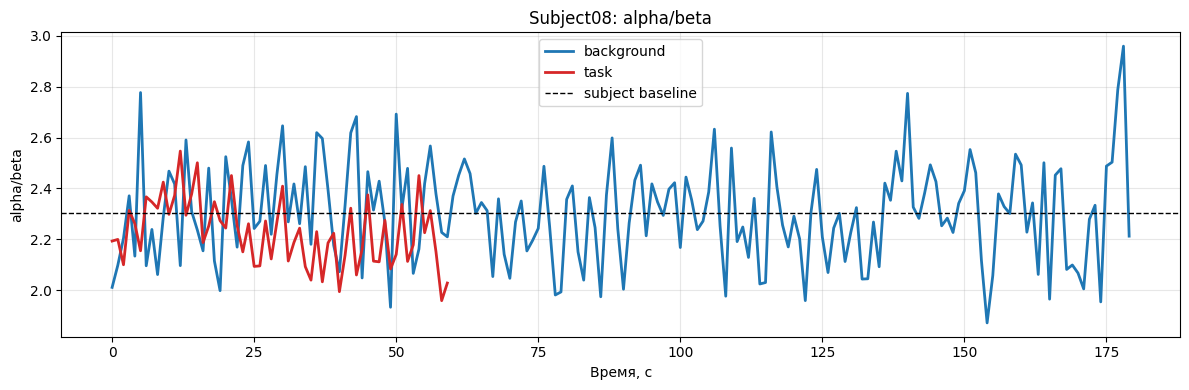

In [ ]:
# Берем субъекта с медианным alpha/beta в фоне, чтобы не попадать в выбросы
example_subject = pivot.iloc[
    (pivot["alpha_beta_background"] - pivot["alpha_beta_background"].median())
    .abs()
    .argsort()
].iloc[0]["subject"]
example = features_df[features_df["subject"] == example_subject].copy()

# Персональный baseline: средний уровень alpha/beta в фоне для этого субъекта
baseline = example.loc[example["condition"] == "background", "alpha_beta"]
mu = baseline.mean()

# Классификация по абсолютному alpha/beta относительно baseline
def classify_state_abs(alpha_beta: float, baseline_mean: float) -> str:
    if alpha_beta >= baseline_mean + 0.15:
        return "Расслабленное"
    if alpha_beta <= baseline_mean - 0.15:
        return "Напряженная умственная деятельность"
    return "Умеренная активность"

example["state"] = example["alpha_beta"].apply(lambda x: classify_state_abs(x, mu))
example["time_s"] = example["epoch_idx"] * 1.0  # шаг 1 сек при окне 2 сек и overlap=1

fig, ax = plt.subplots(figsize=(12, 4))
for condition, color in [("background", "tab:blue"), ("task", "tab:red")]:
    part = example[example["condition"] == condition]
    ax.plot(
        part["time_s"], part["alpha_beta"], label=condition, color=color, linewidth=2
    )

ax.axhline(mu, ls="--", color="black", lw=1, label="subject baseline")
ax.set_title(f"{example_subject}: alpha/beta")
ax.set_xlabel("Время, с")
ax.set_ylabel("alpha/beta")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

example.groupby("condition")["state"].value_counts(normalize=True).rename("share").mul(
    100
).round(1)

In [ ]:
mean_background = pivot["alpha_beta_background"].mean()
mean_task = pivot["alpha_beta_task"].mean()
mean_delta = pivot["delta_alpha_beta"].mean()

print("Общее заключение по выборке:")
print(f"1) Средний Alpha/Beta в фоне: {mean_background:.3f}")
print(f"2) Средний Alpha/Beta при ментальной арифметике: {mean_task:.3f}")
print(f"3) Среднее изменение (task - background): {mean_delta:.3f}")

if mean_delta < 0:
    print(
        "Вывод: в среднем при задаче наблюдается сдвиг к более напряженному состоянию."
    )
else:
    print(
        "Вывод: в среднем при задаче напряжение не увеличилось по индексу Alpha/Beta."
    )

print()
for grp in ["B", "G"]:
    part = pivot[pivot["group"] == grp]
    if len(part) == 0:
        continue
    print(
        f"Группа {grp}: mean delta_alpha_beta = {part['delta_alpha_beta'].mean():.3f}"
    )

Общее заключение по выборке:
1) Средний Alpha/Beta в фоне: 2.299
2) Средний Alpha/Beta при ментальной арифметике: 2.056
3) Среднее изменение (task - background): -0.244
Вывод: в среднем при задаче наблюдается сдвиг к более напряженному состоянию.

Группа B: mean delta_alpha_beta = -0.237
Группа G: mean delta_alpha_beta = -0.246
